<a href="https://colab.research.google.com/github/omar192501/stock_market_trend_analysis-prediction/blob/main/stock_market_trend_analysis%26prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [2]:
stock=yf.download('AAPL',start='2021-01-01',end='2025-01-01')
display(stock.head())
print(stock.shape)

/tmp/ipykernel_18604/3250346703.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock=yf.download('AAPL',start='2021-01-01',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.856705,129.941379,123.279466,129.853854,143301900
2021-01-05,127.412781,128.122747,124.903619,125.350996,97664900
2021-01-06,123.123856,127.451673,122.909895,124.213106,155088000
2021-01-07,127.325218,128.015730,124.349242,124.835513,109578200
2021-01-08,128.424210,128.988286,126.654176,128.793766,105158200


(1005, 5)


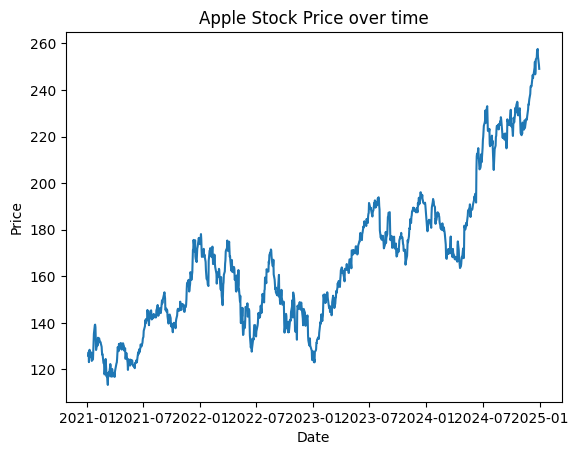

In [3]:
plt.figure()
plt.plot(stock['Close'])
plt.title('Apple Stock Price over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

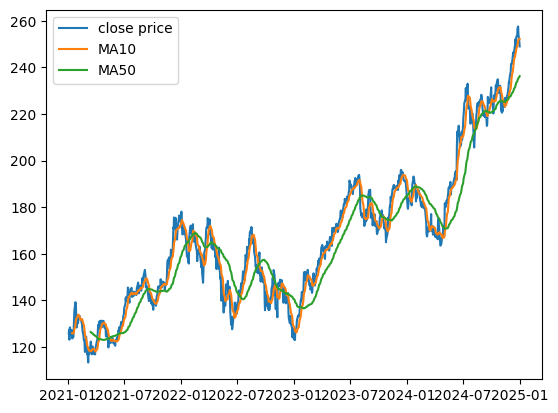

In [4]:
stock['MA10']=stock['Close'].rolling(window=10).mean()
stock['MA50']=stock['Close'].rolling(window=50).mean()
plt.figure()
plt.plot(stock['Close'],label='close price')
plt.plot(stock['MA10'],label='MA10')
plt.plot(stock['MA50'],label='MA50')
plt.legend()
plt.show()

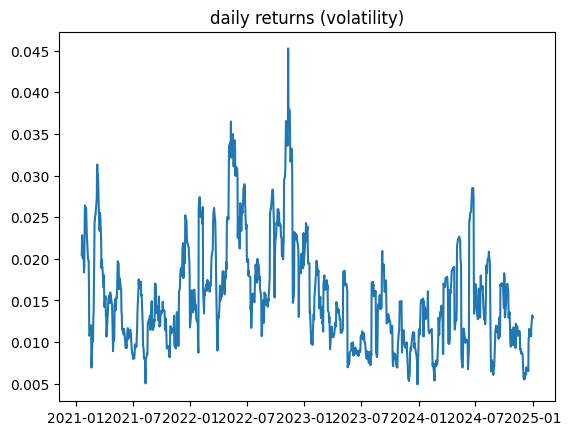

In [5]:
stock['returns']=stock['Close'].pct_change().rolling(10).std()
plt.figure()
plt.plot(stock['returns'])
plt.title('daily returns (volatility)')
plt.show()

In [6]:
stock['prediction']=stock['Close'].shift(-1)
stock=stock.dropna()

In [7]:
x=stock[['Close','MA10','MA50','returns']]
y=stock['prediction']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [9]:
model=RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

In [10]:
pred=model.predict(x_test)

In [11]:
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,pred)
r2=r2_score(y_test,pred)
print("MSE",mse)
print("RMSE",rmse)
print("MAE",mae)
print("R2",r2)

MSE 10.391089336272406
RMSE 3.2235212635055484
MAE 2.305723294163249
R2 0.9891174609554494


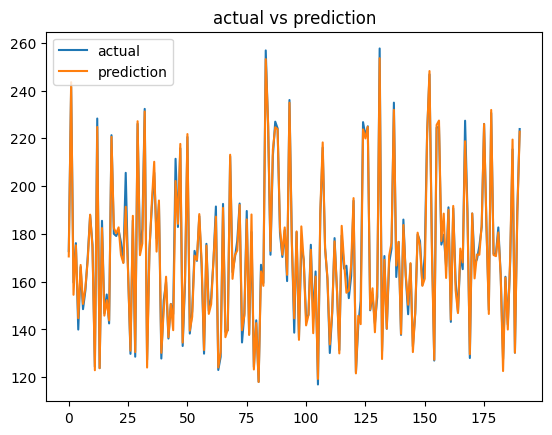

In [12]:
plt.figure()
plt.plot(y_test.values,label='actual')
plt.plot(pred,label='prediction')
plt.legend()
plt.title('actual vs prediction')
plt.show()

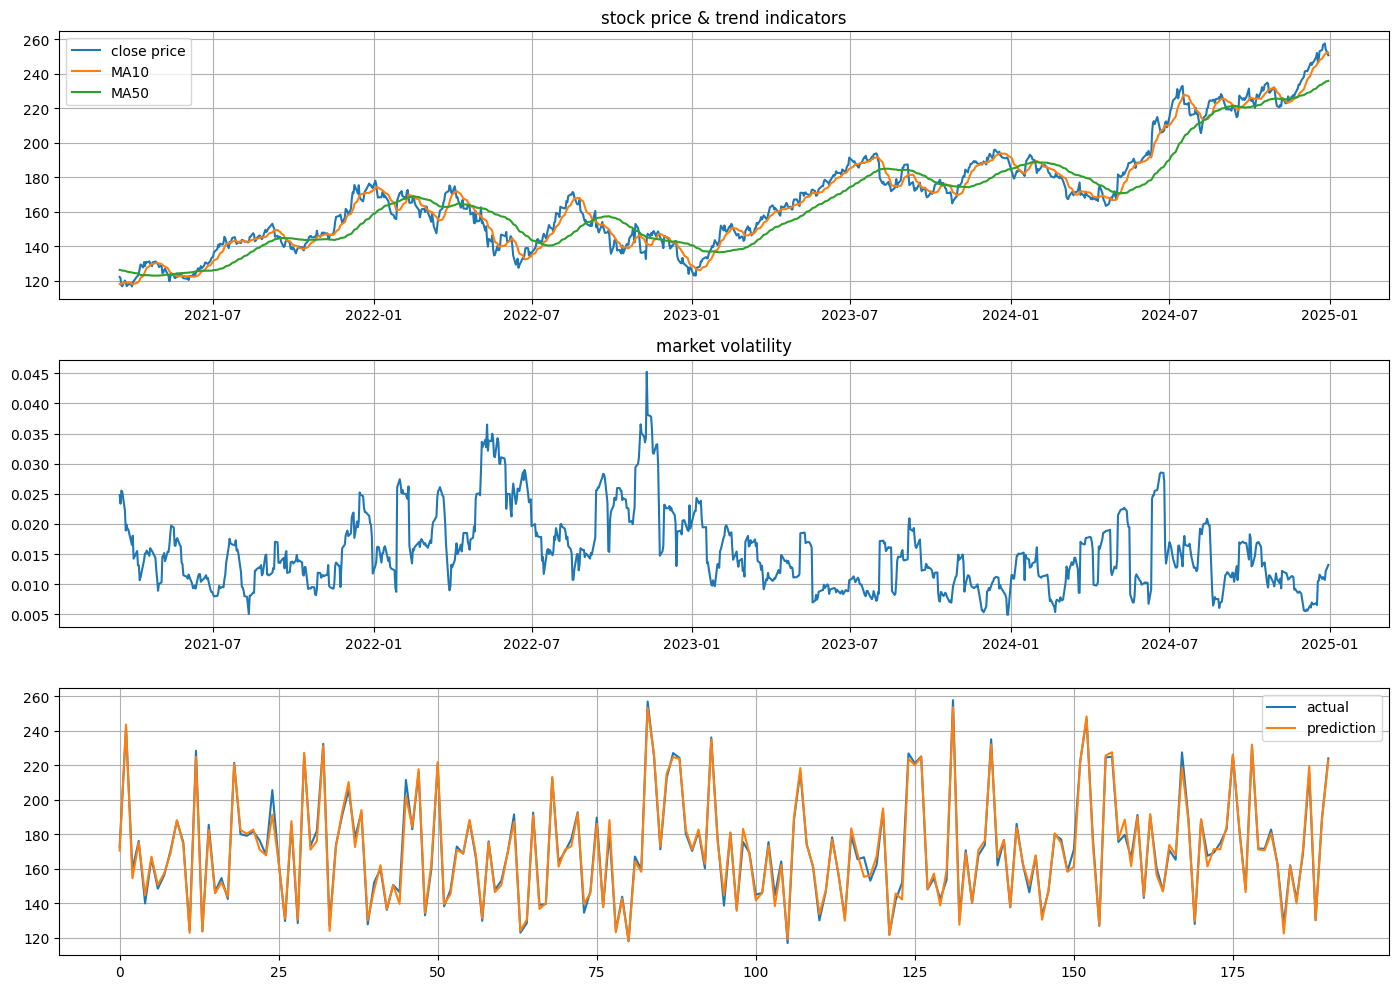

In [13]:
plt.figure(figsize=(14,10))
plt.subplot(3,1,1)
plt.plot(stock['Close'],label='close price')
plt.plot(stock['MA10'],label='MA10')
plt.plot(stock['MA50'],label='MA50')
plt.title("stock price & trend indicators")
plt.legend()
plt.grid()
plt.subplot(3,1,2)
plt.plot(stock['returns'])
plt.title('market volatility')
plt.grid()
plt.subplot(3,1,3)
plt.plot(y_test.values,label='actual')
plt.plot(pred,label='prediction')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()